# VAE Portfolio Project - Data Exploration

This notebook loads historical market data for multiple stock indices and explores their characteristics.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import PortfolioDataLoader
from utils import PortfolioConfig

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

ModuleNotFoundError: No module named 'yfinance'

## 1. Load Configuration and Data

In [ ]:
config = PortfolioConfig()
print(f"Start Date: {config.start_date}")
print(f"End Date: {config.end_date}")

Start Date: 1990-01-01
End Date: 2026-06-01


In [ ]:
loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
prices = loader.fetch_data()

print(prices.head())
print(f"\nShape: {prices.shape}")

Ticker             AGG       CL=F         DIA   DX-Y.NYB        EEM  \
Date                                                                  
2004-11-18  102.739998  46.220001  106.000000  83.690002  21.372223   
2004-11-19  102.529999  48.439999  104.570000  83.309998  21.066668   
2004-11-22  102.690002  48.639999  104.800003  83.190002  21.148890   
2004-11-24  102.730003  49.439999  105.029999  82.410004  21.411112   
2004-11-29  102.150002  49.759998  104.470001  81.930000  21.633333   

Ticker            EFA     ES=F        EWA        EWC        EWG  ...  \
Date                                                             ...   
2004-11-18  51.483334  1185.00  16.530001  16.780001  17.559999  ...   
2004-11-19  51.150002  1172.25  16.520000  16.920000  17.450001  ...   
2004-11-22  51.299999  1178.00  16.440001  17.160000  17.540001  ...   
2004-11-24  51.633331  1182.00  16.820000  17.299999  17.770000  ...   
2004-11-29  52.099998  1176.00  16.959999  17.309999  18.040001  ...  

## 2. Calculate Returns

In [ ]:
returns = loader.calculate_returns(method='log')

print(returns.head())
print("\nReturns statistics:")
print(returns.describe())

print("\nSkewness:")
print(returns.skew())
print("\nKurtosis:")
print(returns.kurtosis())

Ticker           AGG      CL=F       DIA  DX-Y.NYB       EEM       EFA  \
Date                                                                     
2004-11-19 -0.002046  0.046913 -0.013582 -0.004551 -0.014400 -0.006496   
2004-11-22  0.001559  0.004120  0.002197 -0.001441  0.003895  0.002928   
2004-11-24  0.000389  0.016314  0.002192 -0.009420  0.012323  0.006477   
2004-11-29 -0.005662  0.006452 -0.005346 -0.005842  0.010325  0.008998   
2004-11-30  0.000489 -0.012742 -0.001341 -0.001344  0.001847 -0.006740   

Ticker          ES=F       EWA       EWC       EWG  ...     ^FCHI     ^FTSE  \
Date                                                ...                       
2004-11-19 -0.010818 -0.000605  0.008309 -0.006284  ... -0.008287 -0.009304   
2004-11-22  0.004893 -0.004854  0.014085  0.005144  ... -0.006478 -0.005835   
2004-11-24  0.003390  0.022851  0.008125  0.013028  ... -0.003597 -0.002899   
2004-11-29 -0.005089  0.008289  0.000578  0.015080  ...  0.005280  0.006421   
2004-11

## 3. Data Summary Statistics

In [ ]:
summary = loader.get_data_summary()
summary_df = pd.DataFrame(summary)
print(summary_df)

              mean       std       min       max    sharpe
Ticker                                                    
AGG      -0.000008  0.003740 -0.068525  0.058760 -0.033911
CL=F      0.000278  0.030279 -0.282206  0.646280  0.145954
DIA       0.000365  0.012355 -0.136521  0.111942  0.469169
DX-Y.NYB  0.000036  0.005263 -0.036842  0.036224  0.110060
EEM       0.000271  0.018704 -0.176334  0.157845  0.230313
EFA       0.000168  0.014637 -0.118369  0.131463  0.181768
ES=F      0.000429  0.013134 -0.109552  0.117658  0.518212
EWA       0.000147  0.018737 -0.175623  0.140275  0.124387
EWC       0.000291  0.015437 -0.142970  0.138191  0.298916
EWG       0.000212  0.017124 -0.135692  0.150481  0.196743
EWH       0.000161  0.016285 -0.131247  0.133531  0.156837
EWJ       0.000186  0.013955 -0.109901  0.141534  0.211516
EWQ       0.000162  0.017214 -0.135717  0.145819  0.149664
EWS       0.000170  0.015924 -0.118318  0.225453  0.169746
EWU       0.000076  0.015678 -0.128089  0.169239  0.0771

## 4. Visualization - Returns Distribution

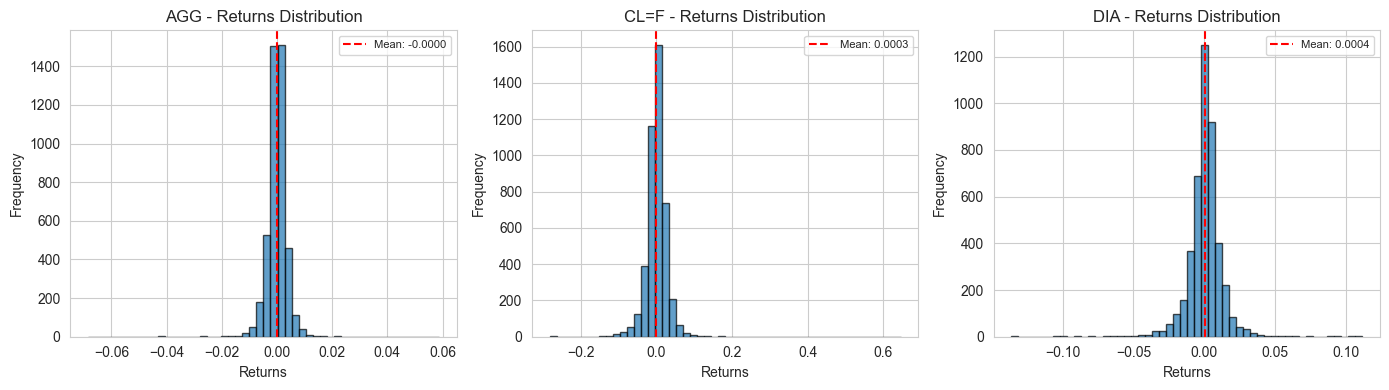

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
top_assets = returns.columns[:3]

for idx, col in enumerate(top_assets):
    axes[idx].hist(returns[col], bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} - Returns Distribution')
    axes[idx].set_xlabel('Returns')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(returns[col].mean(), color='red', linestyle='--', label=f'Mean: {returns[col].mean():.4f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/01_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Matrix

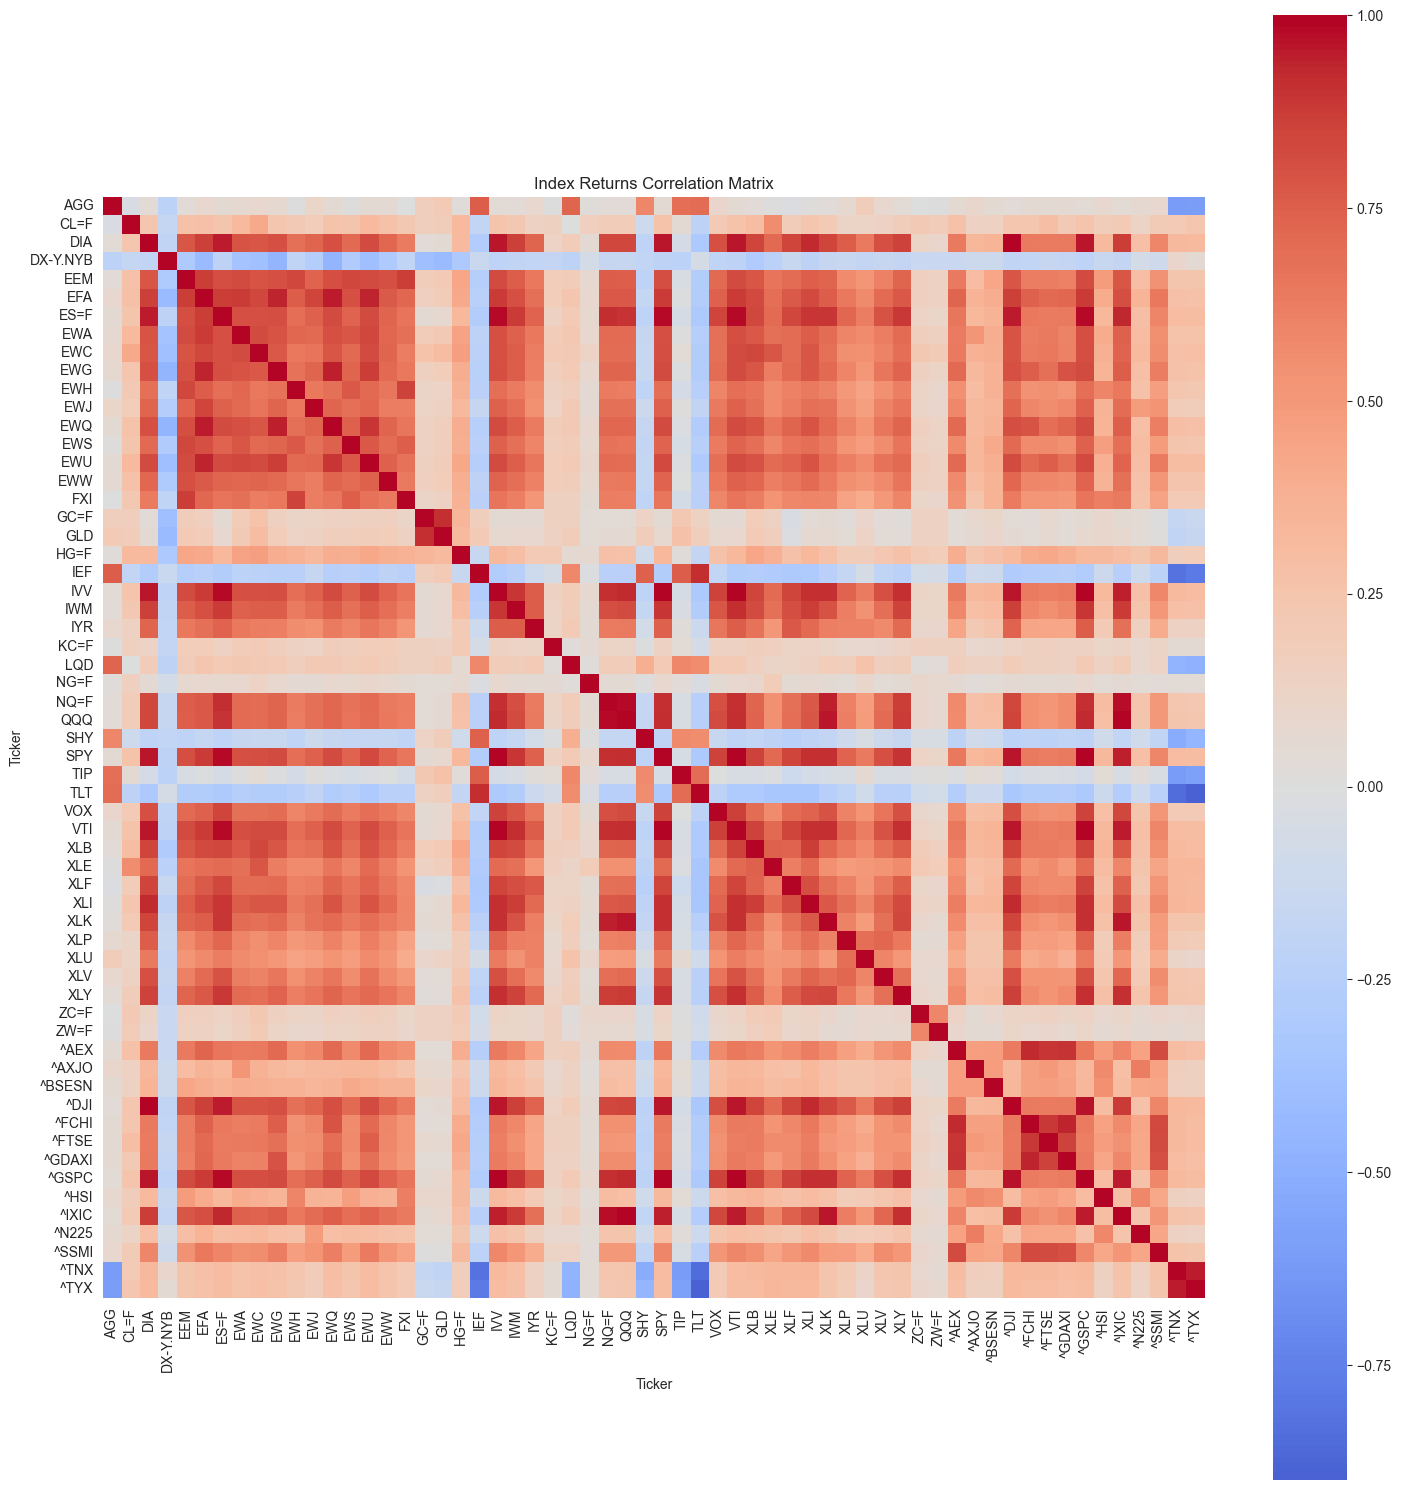

In [ ]:
corr_matrix = returns.corr()
n_assets = len(returns.columns)

fig_size = max(12, n_assets * 0.25)
plt.figure(figsize=(fig_size, fig_size))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Index Returns Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Time Series Plot

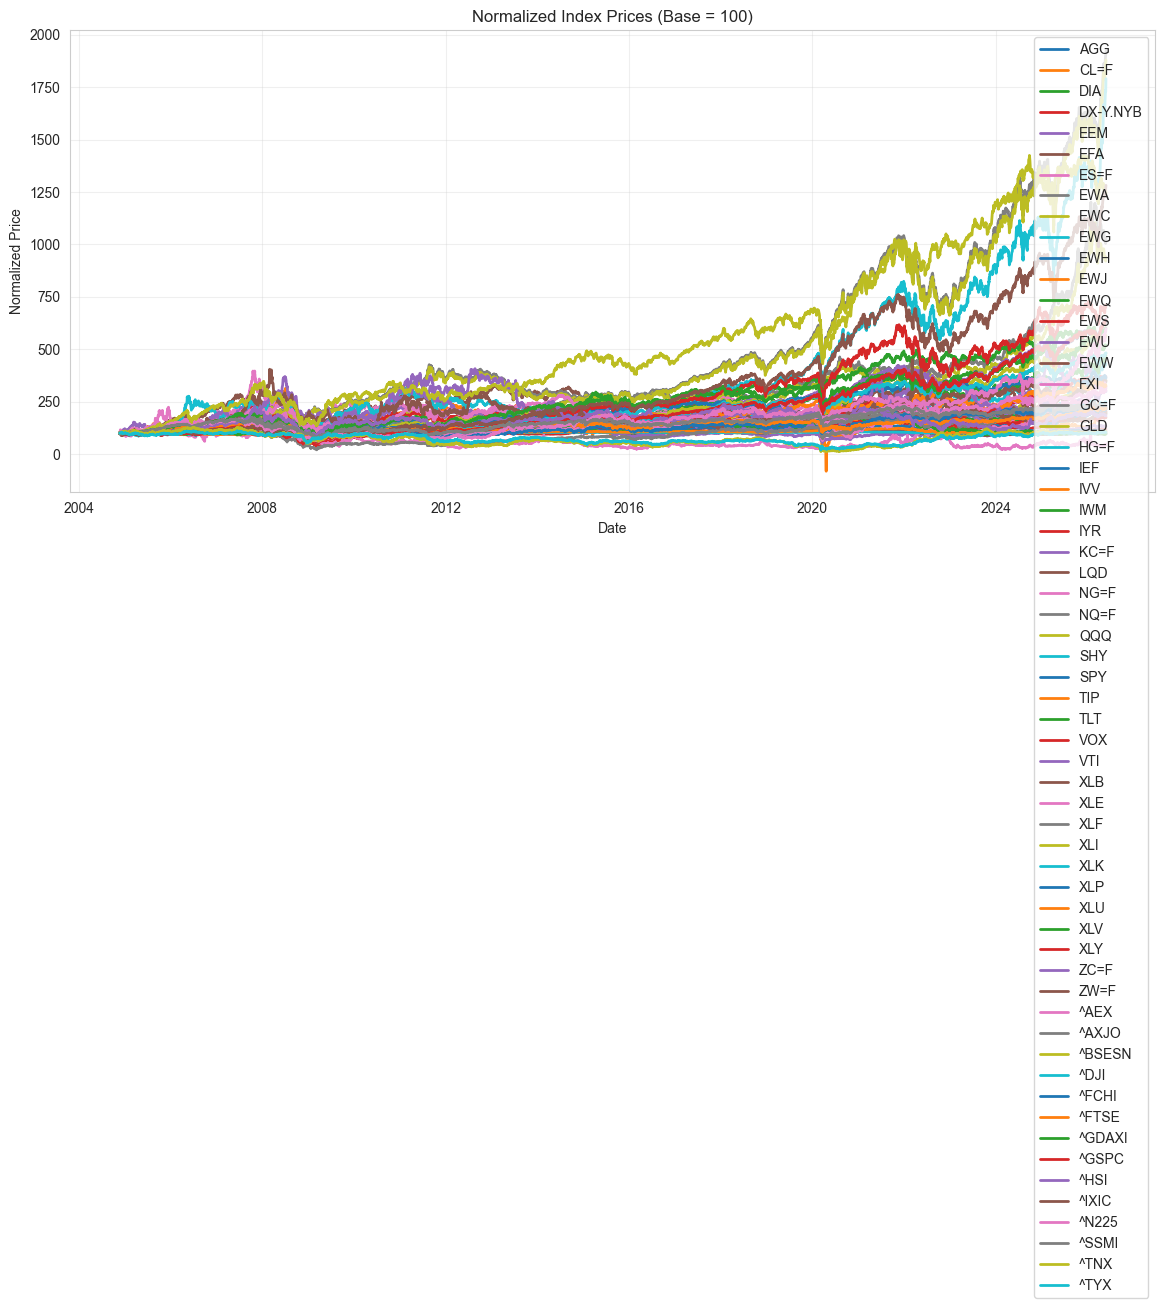

In [ ]:
# prices rebased to 100
prices_normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 6))
for col in prices_normalized.columns:
    plt.plot(prices_normalized.index, prices_normalized[col], label=col, linewidth=2)

plt.title('Normalized Index Prices (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/03_price_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Processed Data

In [ ]:
returns.to_csv('../data/returns.csv', index=True)
prices.to_csv('../data/prices.csv', index=True)